In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path


base = Path.cwd()

file_path = base.parent.parent / "Data" / "Continuous" / "Concrete_Data.xls"

print(file_path)
print(file_path.exists())

df = pd.read_excel(file_path)
df.head()

c:\Users\takun\OneDrive\Desktop\Stats\Stats\Data\Continuous\Concrete_Data.xls
True


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [ ]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [ ]:
df.shape

(1030, 9)

In [ ]:
for i in range(len(df.columns)):
    print(i, df.columns[i], df[df.columns[i]].dtype, df[df.columns[i]].isnull().sum(), df[df.columns[i]].nunique())

0 Cement (component 1)(kg in a m^3 mixture) float64 0 280
1 Blast Furnace Slag (component 2)(kg in a m^3 mixture) float64 0 187
2 Fly Ash (component 3)(kg in a m^3 mixture) float64 0 163
3 Water  (component 4)(kg in a m^3 mixture) float64 0 205
4 Superplasticizer (component 5)(kg in a m^3 mixture) float64 0 155
5 Coarse Aggregate  (component 6)(kg in a m^3 mixture) float64 0 284
6 Fine Aggregate (component 7)(kg in a m^3 mixture) float64 0 304
7 Age (day) int64 0 14
8 Concrete compressive strength(MPa, megapascals)  float64 0 938


In [ ]:
for col in df.columns:
    print(repr(col))

'Cement (component 1)(kg in a m^3 mixture)'
'Blast Furnace Slag (component 2)(kg in a m^3 mixture)'
'Fly Ash (component 3)(kg in a m^3 mixture)'
'Water  (component 4)(kg in a m^3 mixture)'
'Superplasticizer (component 5)(kg in a m^3 mixture)'
'Coarse Aggregate  (component 6)(kg in a m^3 mixture)'
'Fine Aggregate (component 7)(kg in a m^3 mixture)'
'Age (day)'
'Concrete compressive strength(MPa, megapascals) '


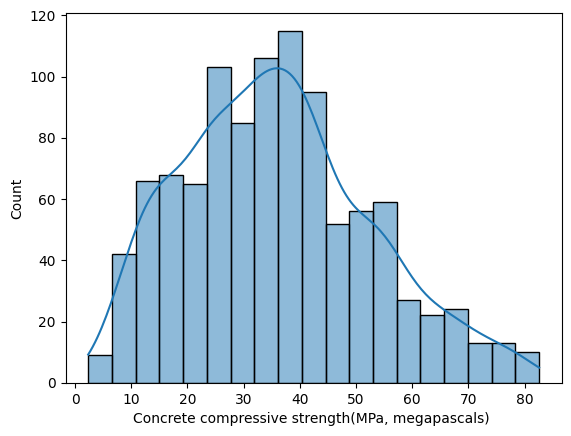

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



sns.histplot(df['Concrete compressive strength(MPa, megapascals) '], kde=True)

plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X, feature_names=None):
    if isinstance(X, pd.DataFrame):
        X_arr = X.values
    else:
        X_arr = np.asarray(X)
        if feature_names is None:
            feature_names = [f"x{i+1}" for i in range(X_arr.shape[1])]
            
    #drop columns that are constant/ all zero, since VIF is undefined for them
    valid_cols = []
    for i in range(X_arr.shape[1]):
        col = X_arr[:, i]
        if np.nanstd(col) == 0:
            print("Skipping '{feature_names[i]}': constant column (VIF Undefined)")
            continue
        valid_cols.append(i)    
    X_valid = X_arr[:, valid_cols]
    valid_names = [feature_names[i] for i in valid_cols]
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = valid_names
    vif_data["VIF"] = [
        variance_inflation_factor(X_valid, i) for i in range(X_valid.shape[1])
    ]
    
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

def transform_data(df, target, test_size=0.2, random_state=42):
    y = df[target].values
    df = df.drop(columns=[target])
    
    dropped_constant_cols = []
    for col in df.columns:
        if df[col].nunique() < 2:
            dropped_constant_cols.append(col)
    if dropped_constant_cols:
        print(f"Dropping constant column(s) (nunique < 2): {dropped_constant_cols}")
        df = df.drop(columns=dropped_constant_cols)
        
    
    df = df.replace([np.inf, -np.inf], np.nan)
    
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    
    df_train, df_test, y_train, y_test = train_test_split(
        df, y, test_size=test_size, random_state=random_state)
    
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_cols)
    ])
    
    X_train = preprocessor.fit_transform(df_train)
    X_test = preprocessor.transform(df_test)
    
    return X_train, X_test, y_train, y_test, preprocessor

        

In [ ]:
vif_results = calculate_vif(df,df.columns)
print(vif_results)

                                             feature        VIF
0          Water  (component 4)(kg in a m^3 mixture)  92.512523
1  Coarse Aggregate  (component 6)(kg in a m^3 mi...  85.900013
2  Fine Aggregate (component 7)(kg in a m^3 mixture)  73.522864
3          Cement (component 1)(kg in a m^3 mixture)  26.248178
4   Concrete compressive strength(MPa, megapascals)   14.555916
5  Superplasticizer (component 5)(kg in a m^3 mix...   5.520316
6         Fly Ash (component 3)(kg in a m^3 mixture)   4.561734
7  Blast Furnace Slag (component 2)(kg in a m^3 m...   4.444466
8                                          Age (day)   2.434882


In [ ]:
# instead of using raw Age, try log-transforming it before scaling
df['Age_log'] = np.log1p(df['Age (day)'])
df.drop(columns=['Age (day)'],inplace=True)

In [ ]:
import statsmodels.api as sm 
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from itertools import product

X_train, X_test, y_train, y_test, preprocessor = transform_data(df, target='Concrete compressive strength(MPa, megapascals) ')

#Grid fo hyperparameters to try
alphas = [1.0, 2.5, 5.0, 10.0]
l1_wts =  [0.0, 0.25, 0.5, 0.75, 1.0]

results = []

for alpha, l1_wt in product(alphas, l1_wts):
    skf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_mse = []
    
    for fold, (fold_train_idx, fold_val_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_fold_train, X_fold_val = X_train[fold_train_idx], X_train[fold_val_idx]
        y_fold_train, y_fold_val = y_train[fold_train_idx], y_train[fold_val_idx]
        
        x_fold_train_const = sm.add_constant(X_fold_train, has_constant='add')
        x_fold_val_const = sm.add_constant(X_fold_val, has_constant='add')
        
        try:
            model = sm.OLS(y_fold_train, x_fold_train_const).fit_regularized(
                 alpha=alpha, L1_wt=l1_wt
            )
        except np.linalg.LinAlgError:
            continue
     
        y_pred = model.predict(x_fold_val_const)
        mse = mean_squared_error(y_fold_val, y_pred)
        fold_mse.append(mse)
    
    mean_mse = np.mean(fold_mse) if fold_mse else np.nan
    std_mse = np.std(fold_mse) if fold_mse else np.nan
    results.append({"alpha": alpha, "L1_wt": l1_wt, "mean_mse": mean_mse, "std_mse": std_mse})
    print(f"alpha={alpha}, l1_wt={l1_wt}: mean MSE={mean_mse:.3f}, std_mse={std_mse:.3f}")
    
results_df = pd.DataFrame(results).sort_values("mean_mse", ascending=True)
print("\n Best hyperparameters (by CV mean MSE on training split only):")
print(results_df.head())

best_alpha = results_df.iloc[0]["alpha"]
best_l1_wt = results_df.iloc[0]["L1_wt"]
        
        

alpha=1.0, l1_wt=0.0: mean MSE=442.273, std_mse=45.897
alpha=1.0, l1_wt=0.25: mean MSE=350.979, std_mse=39.300
alpha=1.0, l1_wt=0.5: mean MSE=248.544, std_mse=30.852
alpha=1.0, l1_wt=0.75: mean MSE=142.250, std_mse=19.805
alpha=1.0, l1_wt=1.0: mean MSE=67.279, std_mse=6.338
alpha=2.5, l1_wt=0.0: mean MSE=833.091, std_mse=73.287
alpha=2.5, l1_wt=0.25: mean MSE=726.365, std_mse=68.256
alpha=2.5, l1_wt=0.5: mean MSE=576.751, std_mse=60.319
alpha=2.5, l1_wt=0.75: mean MSE=359.547, std_mse=45.731
alpha=2.5, l1_wt=1.0: mean MSE=100.791, std_mse=14.597
alpha=5.0, l1_wt=0.0: mean MSE=1109.711, std_mse=89.942
alpha=5.0, l1_wt=0.25: mean MSE=1033.618, std_mse=88.239
alpha=5.0, l1_wt=0.5: mean MSE=909.230, std_mse=84.566
alpha=5.0, l1_wt=0.75: mean MSE=672.414, std_mse=73.925
alpha=5.0, l1_wt=1.0: mean MSE=195.333, std_mse=29.180
alpha=10.0, l1_wt=0.0: mean MSE=1308.187, std_mse=100.970
alpha=10.0, l1_wt=0.25: mean MSE=1274.330, std_mse=102.315
alpha=10.0, l1_wt=0.5: mean MSE=1205.982, std_mse=10

In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# --- shared design matrices ---
X_train_const = sm.add_constant(X_train, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

# --- Regularized model (your existing specification) ---
final_model = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian()).fit_regularized(
    alpha=best_alpha, L1_wt=best_l1_wt
)

y_test_pred_reg = final_model.predict(X_test_const)
test_mse_reg = mean_squared_error(y_test, y_test_pred_reg)

print("=== Regularized GLM ===")
print(f"Held-out test set (n={len(y_test)}), never touched during CV/hyperparameter search:")
print(f"  MSE:      {test_mse_reg:.3f}")
print(f"\nFor comparison, CV mean mse on the training split was: "
      f"{results_df.iloc[0]['mean_mse']:.3f}")

# --- Unregularized model (plain OLS via GLM, alpha=0 equivalent) ---
unreg_model = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian()).fit()

y_test_pred_unreg = unreg_model.predict(X_test_const)
test_mse_unreg = mean_squared_error(y_test, y_test_pred_unreg)

print("\n=== Unregularized GLM (OLS) ===")
print(f"  MSE:      {test_mse_unreg:.3f}")
print(unreg_model.summary())

=== Regularized GLM ===
Held-out test set (n=206), never touched during CV/hyperparameter search:
  MSE:      61.852

For comparison, CV mean mse on the training split was: 67.279

=== Unregularized GLM (OLS) ===
  MSE:      44.582
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  824
Model:                            GLM   Df Residuals:                      815
Model Family:                Gaussian   Df Model:                            8
Link Function:               Identity   Scale:                          53.876
Method:                          IRLS   Log-Likelihood:                -2807.2
Date:                Wed, 29 Jul 2026   Deviance:                       43909.
Time:                        18:16:46   Pearson chi2:                 4.39e+04
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9862
Covariance Type:            nonrobust                    

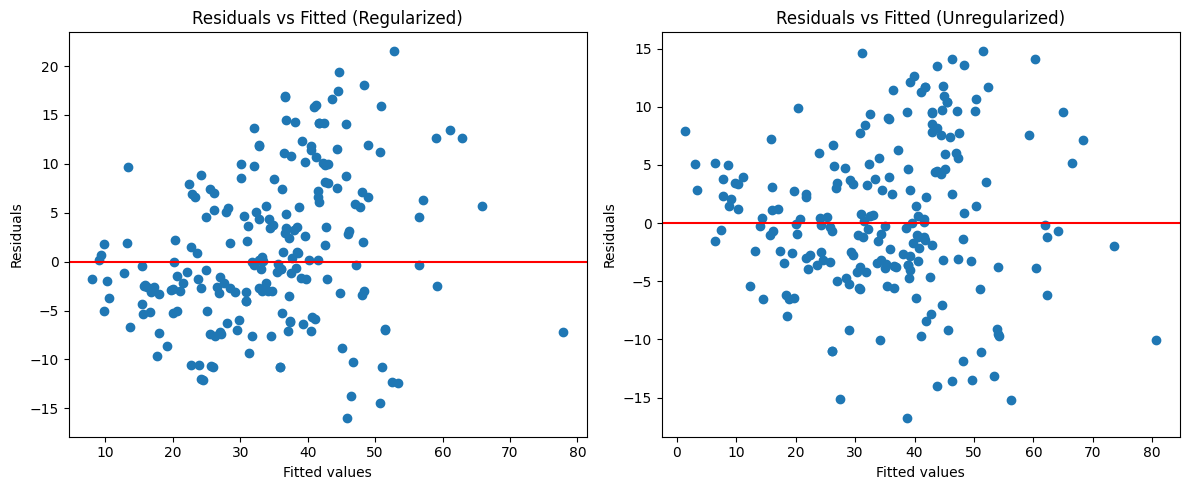

In [ ]:
resid_reg = y_test - y_test_pred_reg
fitted_reg = final_model.predict(X_test_const)

resid_unreg = y_test - y_test_pred_unreg
fitted_unreg = unreg_model.predict(X_test_const)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted_reg, resid_reg)
axes[0].axhline(0, color='red')
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (Regularized)")

axes[1].scatter(fitted_unreg, resid_unreg)
axes[1].axhline(0, color='red')
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted (Unregularized)")

plt.tight_layout()
plt.show()

In [ ]:


# --- basics ---
# fitted = final_model.predict(X_train_const)   # use whichever X/y you fit on
# resid = y_train - fitted
n = len(y_test)
p = X_train_const.shape[1]  # number of params including intercept

X = np.asarray(X_test_const)

# --- hat matrix diagonal (leverage) ---
# H = X (X'X)^-1 X'
XtX_inv = np.linalg.pinv(X.T @ X)   # pinv is safer than inv, especially near-collinear X
H = X @ XtX_inv @ X.T
leverage = np.diag(H)

# --- residual standard error ---
rss = np.sum(resid_unreg**2)
mse = rss / (n - p)

# --- studentized (internal) residuals ---
# e_i / (s * sqrt(1 - h_ii))
student_resid = resid_unreg / np.sqrt(mse * (1 - leverage))

# --- Cook's distance ---
# D_i = (e_i^2 / (p * mse)) * (h_ii / (1 - h_ii)^2)
cooks_d = (resid_unreg**2 / (p * mse)) * (leverage / (1 - leverage)**2)

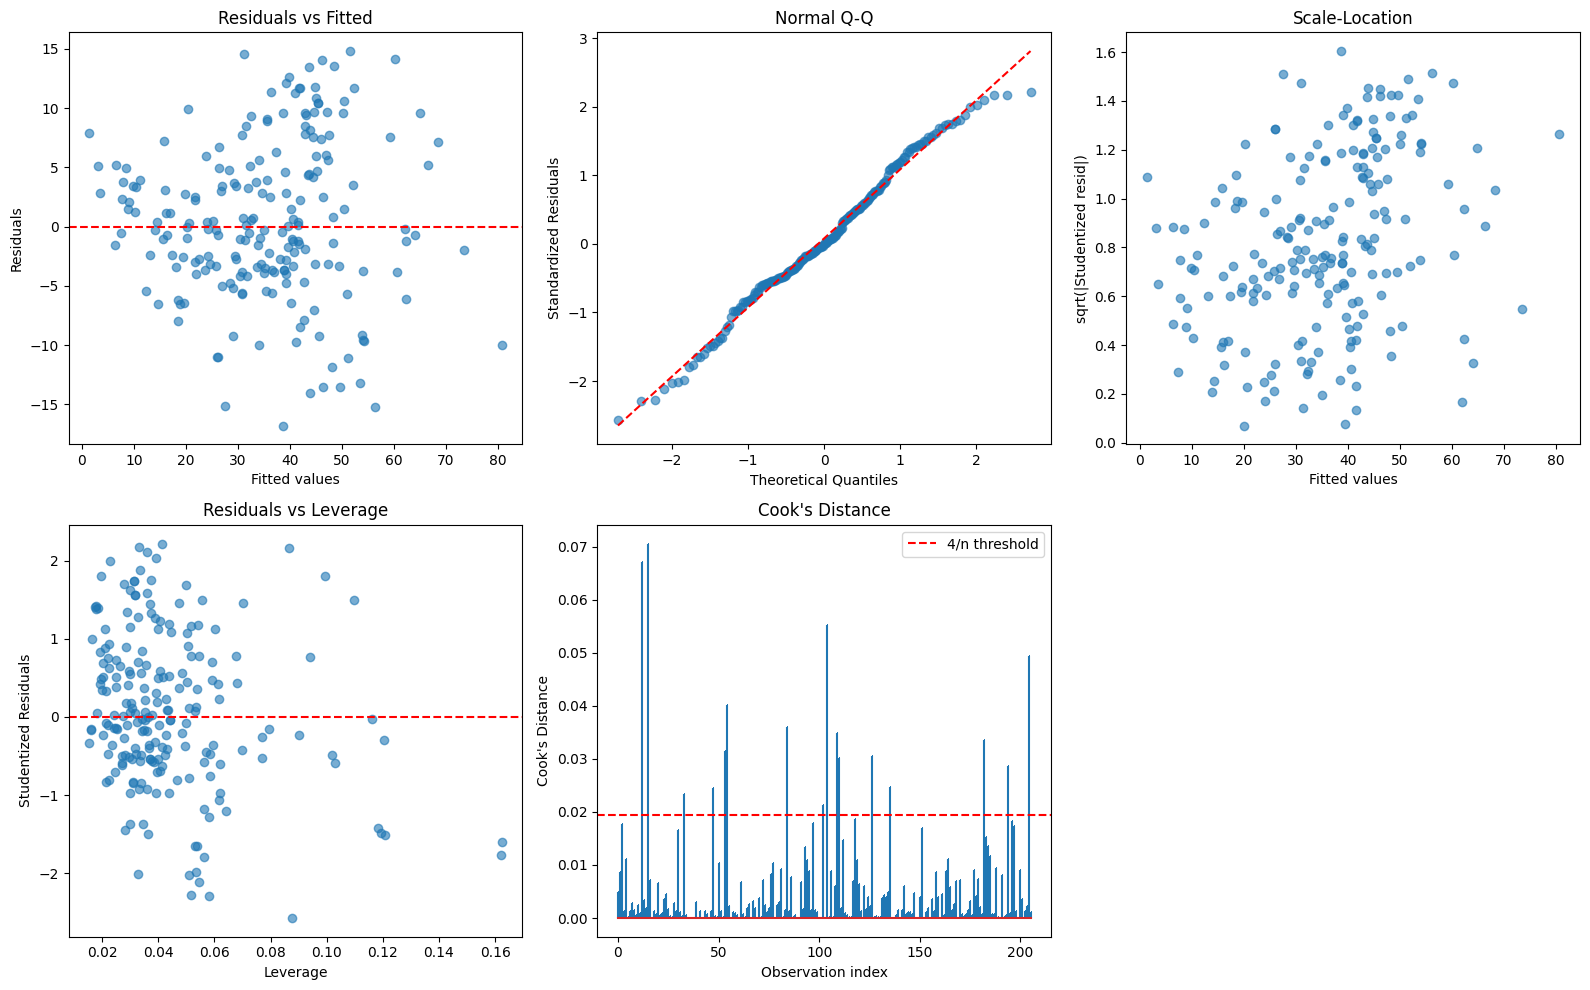

In [ ]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Residuals vs Fitted
axes[0,0].scatter(fitted_unreg, resid_unreg, alpha=0.6)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel("Fitted values")
axes[0,0].set_ylabel("Residuals")
axes[0,0].set_title("Residuals vs Fitted")

# Normal Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(student_resid, dist="norm")
axes[0,1].scatter(osm, osr, alpha=0.6)
axes[0,1].plot(osm, slope * osm + intercept, color='red', linestyle='--')
axes[0,1].set_xlabel("Theoretical Quantiles")
axes[0,1].set_ylabel("Standardized Residuals")
axes[0,1].set_title("Normal Q-Q")

# Scale-Location
axes[0,2].scatter(fitted_unreg, np.sqrt(np.abs(student_resid)), alpha=0.6)
axes[0,2].set_xlabel("Fitted values")
axes[0,2].set_ylabel("sqrt(|Studentized resid|)")
axes[0,2].set_title("Scale-Location")

# Leverage vs Studentized Residuals
axes[1,0].scatter(leverage, student_resid, alpha=0.6)
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_xlabel("Leverage")
axes[1,0].set_ylabel("Studentized Residuals")
axes[1,0].set_title("Residuals vs Leverage")

# Cook's Distance
axes[1,1].stem(np.arange(n), cooks_d, markerfmt=",")
axes[1,1].axhline(4/n, color='red', linestyle='--', label='4/n threshold')
axes[1,1].set_xlabel("Observation index")
axes[1,1].set_ylabel("Cook's Distance")
axes[1,1].set_title("Cook's Distance")
axes[1,1].legend()

axes[1,2].axis('off')  # spare panel, or put a histogram of resid here

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_pvalue, _, _ = het_breuschpagan(unreg_model.resid_response, X_train_const)
print(f"Breusch-Pagan p={bp_pvalue:.4f}")

Breusch-Pagan p=0.0000


In [ ]:
unreg_model_robust = sm.GLM(y_train, X_train_const, family=sm.families.Gaussian()).fit(cov_type='HC3')
print(unreg_model_robust.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  824
Model:                            GLM   Df Residuals:                      815
Model Family:                Gaussian   Df Model:                            8
Link Function:               Identity   Scale:                          53.876
Method:                          IRLS   Log-Likelihood:                -2807.2
Date:                Wed, 29 Jul 2026   Deviance:                       43909.
Time:                        18:16:47   Pearson chi2:                 4.39e+04
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9862
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.8577      0.254    141.005      0.0

In [ ]:
# Build side-by-side comparison table
comparison = pd.DataFrame({
    'coef': unreg_model.params,
    'se_nonrobust': unreg_model.bse,
    'p_nonrobust': unreg_model.pvalues,
    'se_robust_HC3': unreg_model_robust.bse,
    'p_robust_HC3': unreg_model_robust.pvalues,
})

# Flag any variable whose significance (at alpha=0.05) flips between the two
comparison['sig_nonrobust'] = comparison['p_nonrobust'] < 0.05
comparison['sig_robust'] = comparison['p_robust_HC3'] < 0.05
comparison['flipped'] = comparison['sig_nonrobust'] != comparison['sig_robust']

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(comparison)

if comparison['flipped'].any():
    print("\nSignificance flipped (at 0.05) for:", 
          list(comparison[comparison['flipped']].index))
else:
    print("\nNo variables flipped significance at the 0.05 level.")

     coef  se_nonrobust  p_nonrobust  se_robust_HC3  p_robust_HC3  \
0 35.8577        0.2557       0.0000         0.2543        0.0000   
1 14.2099        0.7014       0.0000         0.8000        0.0000   
2 10.1030        0.6816       0.0000         0.8390        0.0000   
3  5.7639        0.6263       0.0000         0.6834        0.0000   
4 -2.7456        0.6520       0.0000         0.8022        0.0006   
5  0.7450        0.4330       0.0854         0.5019        0.1378   
6  2.1415        0.5679       0.0002         0.6758        0.0015   
7  2.9026        0.6658       0.0000         0.7907        0.0002   
8 10.3391        0.2618       0.0000         0.2696        0.0000   

   sig_nonrobust  sig_robust  flipped  
0           True        True    False  
1           True        True    False  
2           True        True    False  
3           True        True    False  
4           True        True    False  
5          False       False    False  
6           True        True 

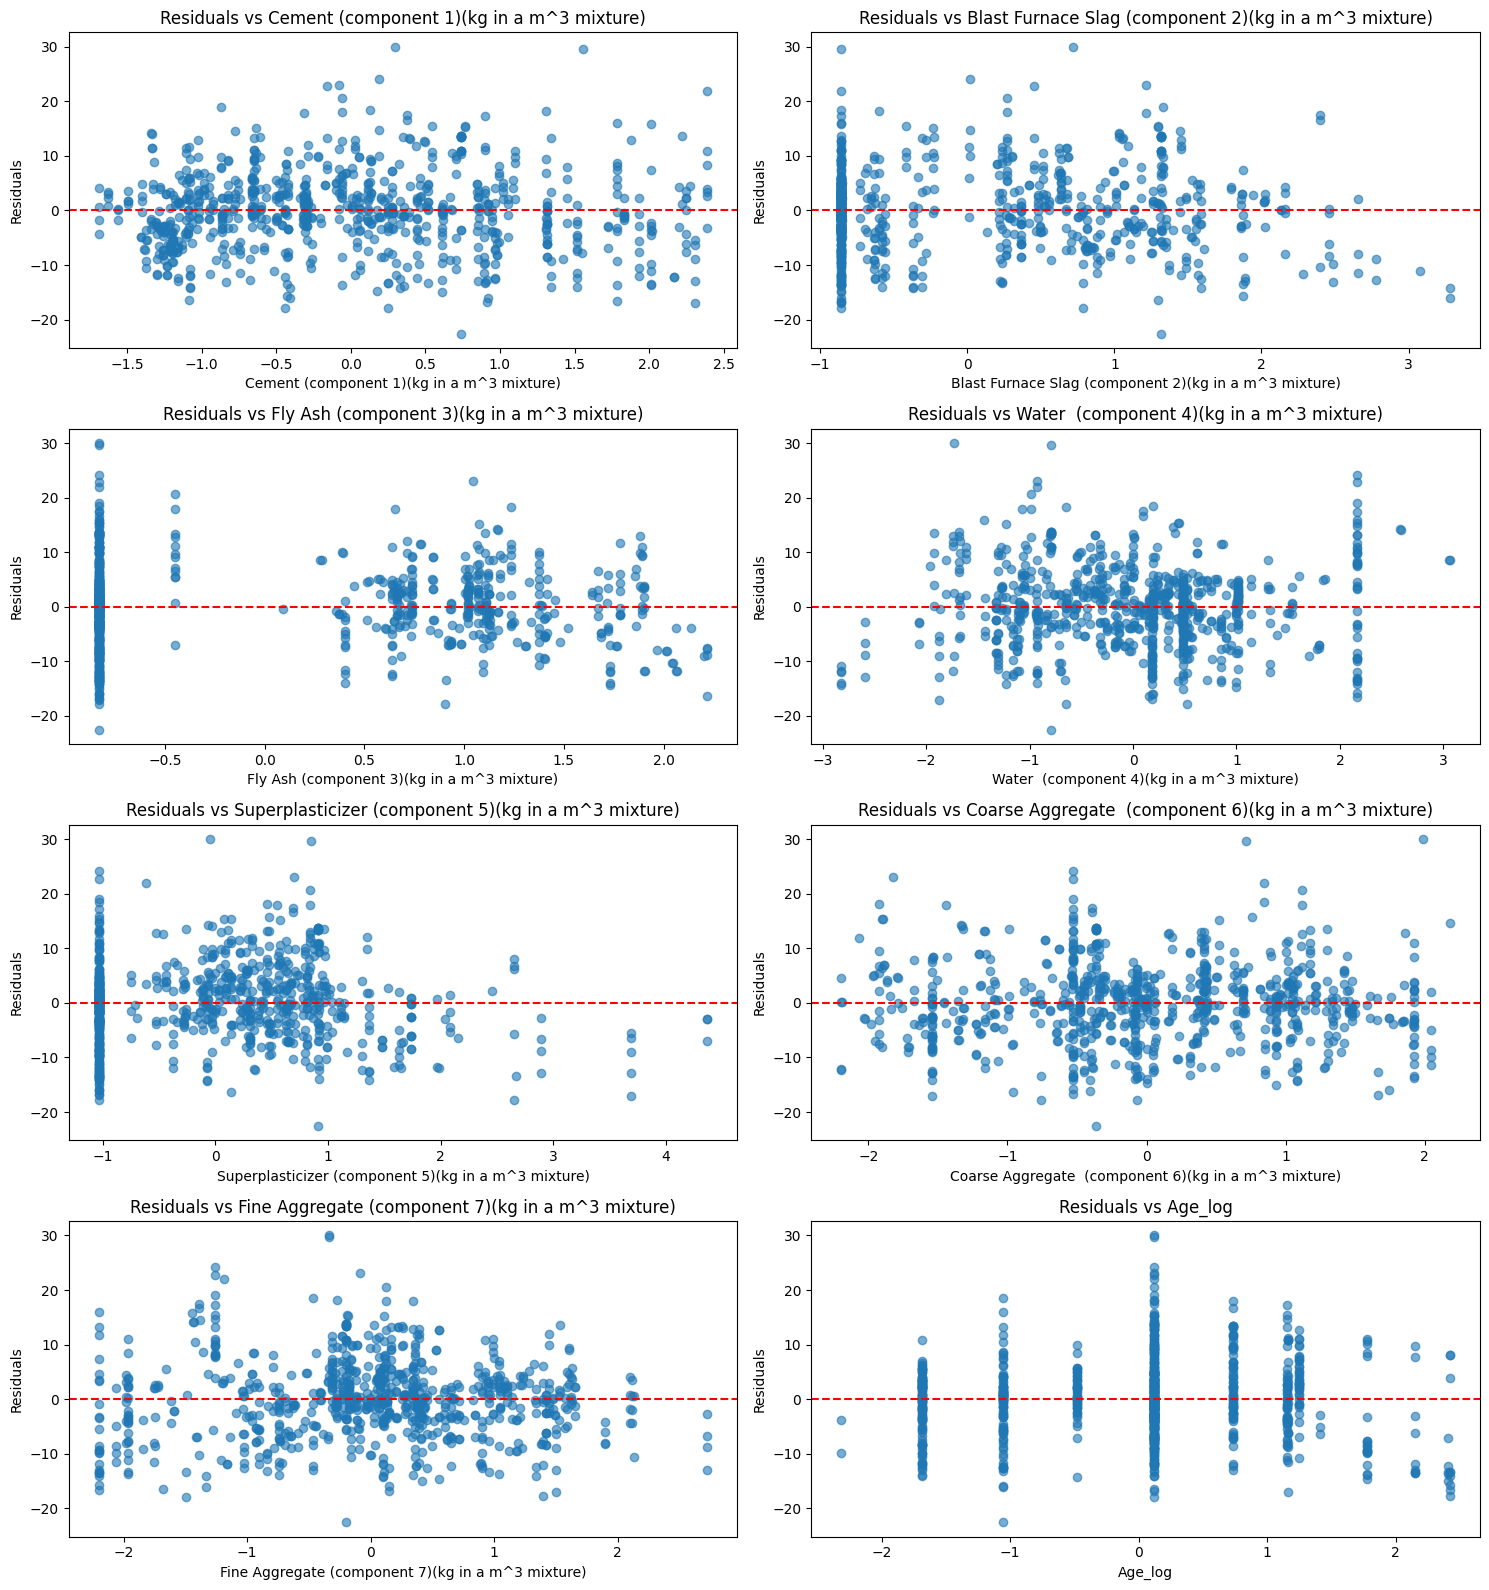

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Get the actual feature names in the order the ColumnTransformer output them
feature_names = preprocessor.named_transformers_['num'].feature_names_in_.tolist()


resid = unreg_model.resid_response

n_vars = len(feature_names)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    axes[i].scatter(X_train[:, i], resid, alpha=0.6)
    # LOWESS smoother
    smooth = lowess(
            resid,
            X_train[:, i],
            frac=0.3,
            return_sorted=True
        )
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Residuals")
    axes[i].set_title(f"Residuals vs {col}")
    axes[i].plot(smooth[:, 0], smooth[:, 1], color='blue', linewidth=2)
    

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

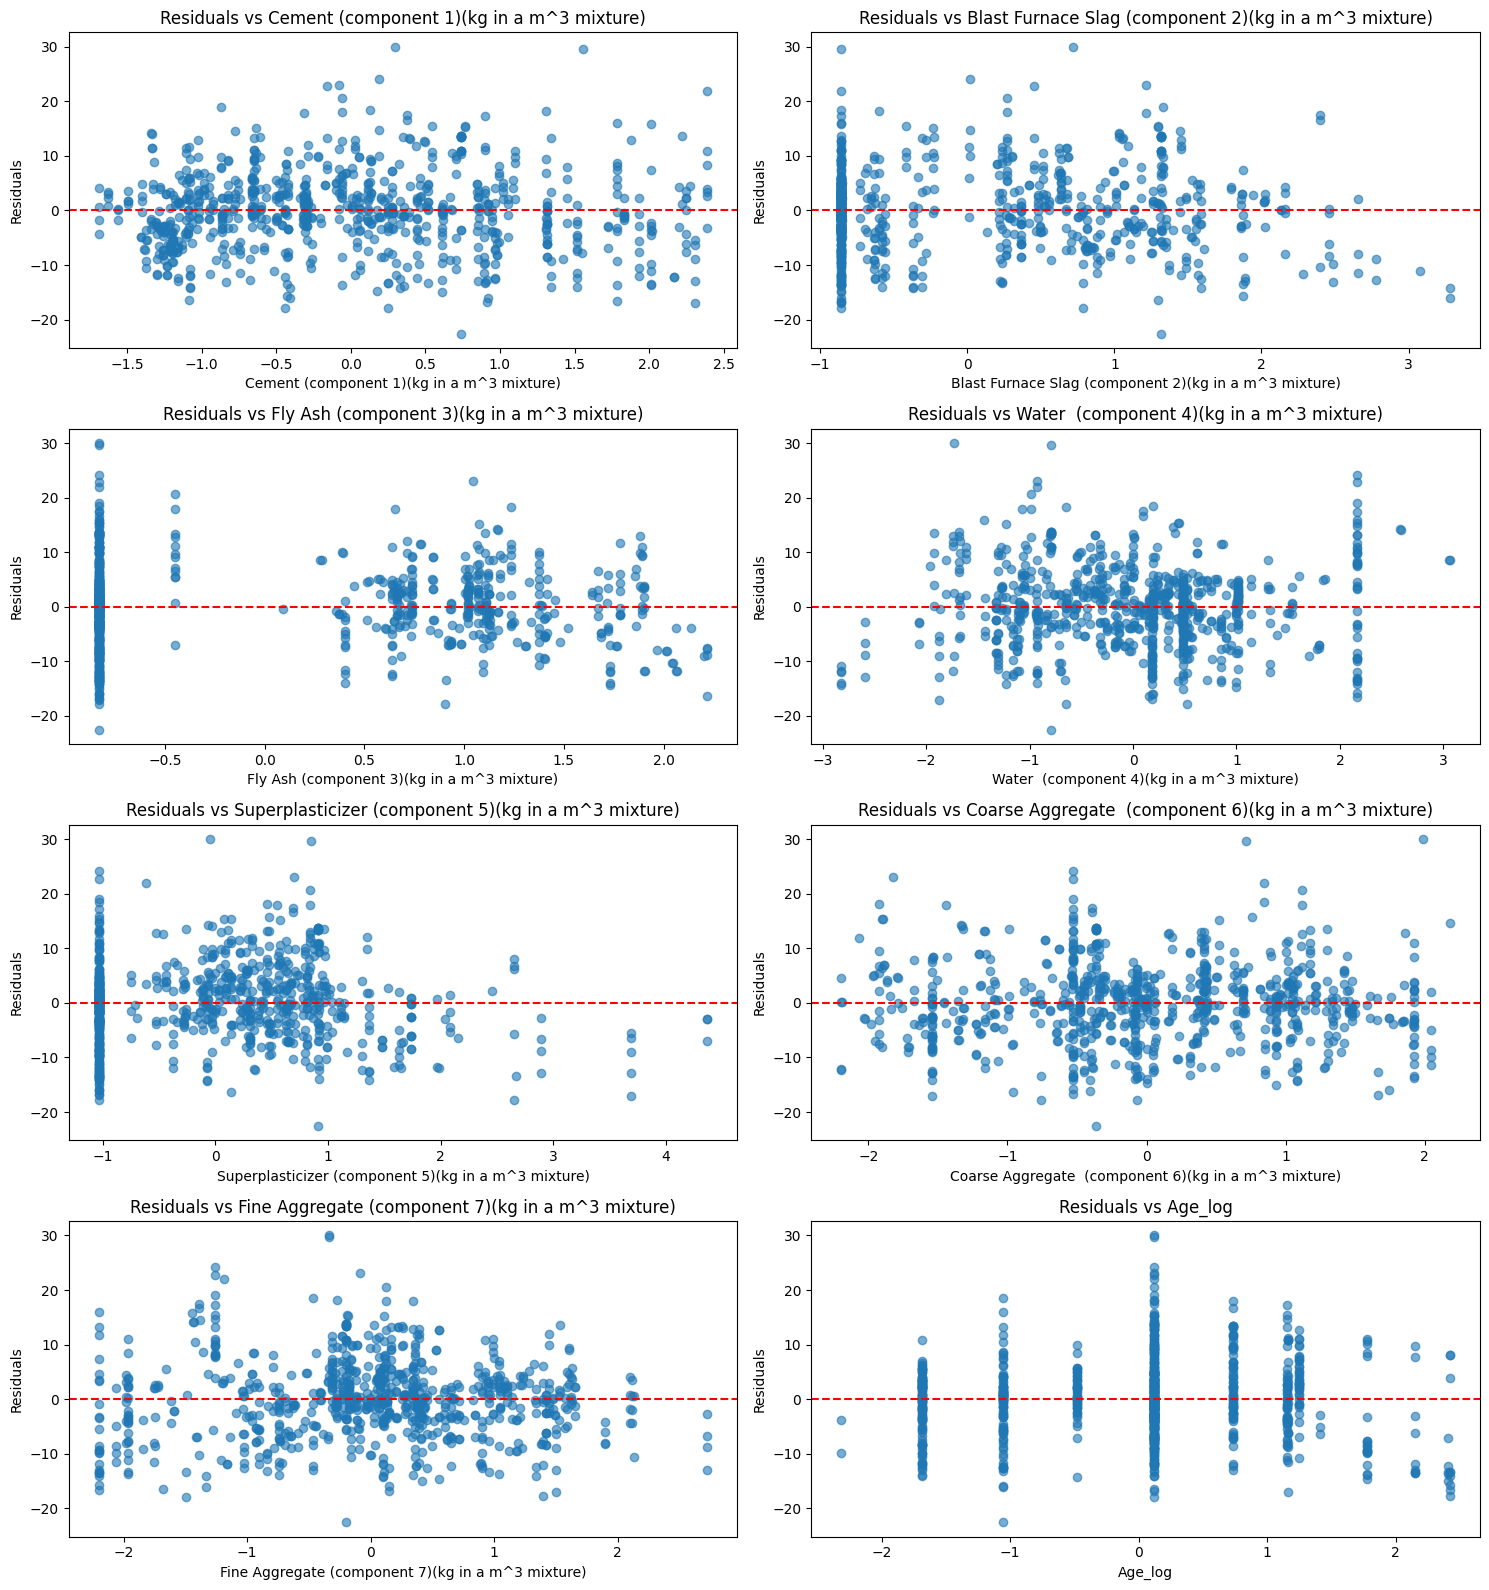

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the actual feature names in the order the ColumnTransformer output them
feature_names = preprocessor.named_transformers_['num'].feature_names_in_.tolist()


resid = unreg_model_robust.resid_response

n_vars = len(feature_names)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    axes[i].scatter(X_train[:, i], resid, alpha=0.6)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Residuals")
    axes[i].set_title(f"Residuals vs {col}")

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:


resid_new = unreg_model_robust.resid_response  

bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(resid_new, X_train_const)
print(f"BP test (with Age_log): stat={bp_stat:.3f}, p={bp_pvalue:.6f}")

# compare directly to the original
print(f"BP test (with raw Age):  p={0.0000:.6f}")  

BP test (with Age_log): stat=84.130, p=0.000000
BP test (with raw Age):  p=0.000000


In [ ]:
resid_sq_new = resid_new**2
aux_model_new = sm.OLS(resid_sq_new, X_train_const).fit()

aux_summary_new = pd.DataFrame({
    'coef': aux_model_new.params,
    'p_value': aux_model_new.pvalues
})
print(aux_summary_new.sort_values('p_value'))

      coef  p_value
0  53.2873   0.0000
8  13.1054   0.0000
7 -31.6352   0.0000
4 -28.0139   0.0002
6 -17.5852   0.0065
3 -16.1134   0.0235
5  -4.6192   0.3472
1  -6.7912   0.3935
2  -5.7910   0.4540


In [ ]:
from pygam import LinearGAM, s
import numpy as np

n_features = X_train.shape[1] 

# Build a smooth (spline) term for every predictor
terms = s(0)
for i in range(1, n_features):
    terms += s(i)

gam = LinearGAM(terms)

# Search over smoothing parameter lambda (controls how wiggly each smooth can be)
lam_grid = np.logspace(-3, 3, 11)  # 0.001 to 1000
gam.gridsearch(X_train, y_train, lam=lam_grid)

print(gam.summary())

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:01
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:01 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:01 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:01 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:01 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:02 Time:  0:00:02


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     93.0789
Link Function:                     IdentityLink Log Likelihood:                                 -2437.5474
Number of Samples:                          824 AIC:                                             5063.2526
                                                AICc:                                            5087.7955
                                                GCV:                                               30.4439
                                                Scale:                                              4.9319
                                                Pseudo R-Squared:                                    0.924
Feature Function                  Lam

C:\Users\takun\AppData\Local\Temp\ipykernel_37108\2488997796.py:17: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [ ]:
from sklearn.metrics import mean_squared_error

y_test_pred_gam = gam.predict(X_test)
test_mse_gam = mean_squared_error(y_test, y_test_pred_gam)

print(f"GAM test MSE: {test_mse_gam:.3f}")
print(f"Unregularized GLM test MSE: {test_mse_unreg:.3f}")
print(f"Regularized GLM test MSE: {test_mse_reg:.3f}")

GAM test MSE: 30.528
Unregularized GLM test MSE: 44.582
Regularized GLM test MSE: 61.852


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mses = []

for train_idx, val_idx in kf.split(X_train):
    gam_cv = LinearGAM(terms).gridsearch(X_train[train_idx], y_train[train_idx], lam=lam_grid, progress=False)
    pred = gam_cv.predict(X_train[val_idx])
    cv_mses.append(mean_squared_error(y_train[val_idx], pred))

print(f"GAM CV MSE: {np.mean(cv_mses):.3f} ± {np.std(cv_mses):.3f}")

GAM CV MSE: 31.105 ± 2.736


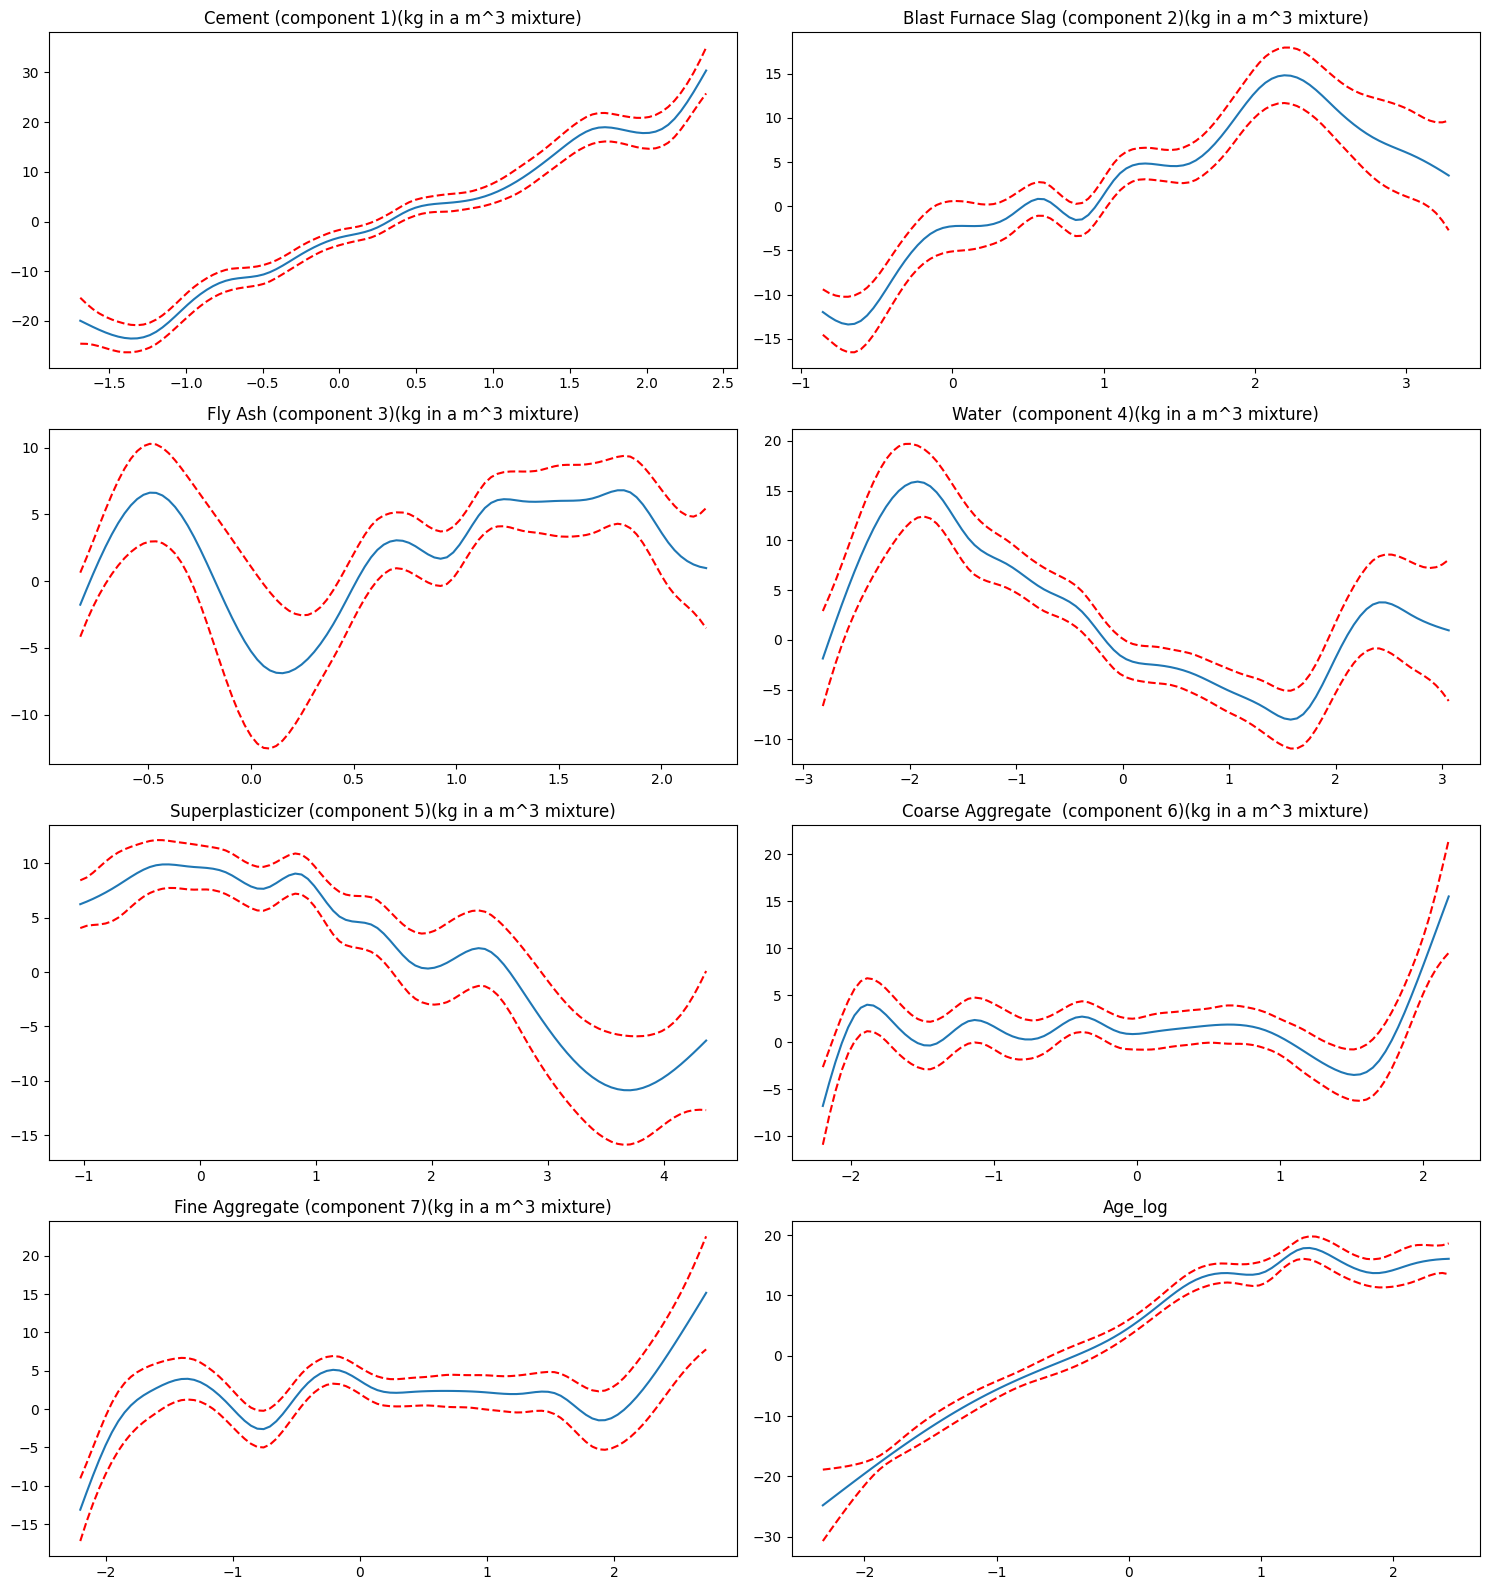

In [ ]:
feature_labels = feature_names  
n_vars = len(feature_names)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, ax in enumerate(axes):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1], c='r', ls='--')
    ax.set_title(feature_labels[i])

plt.tight_layout()
plt.show()

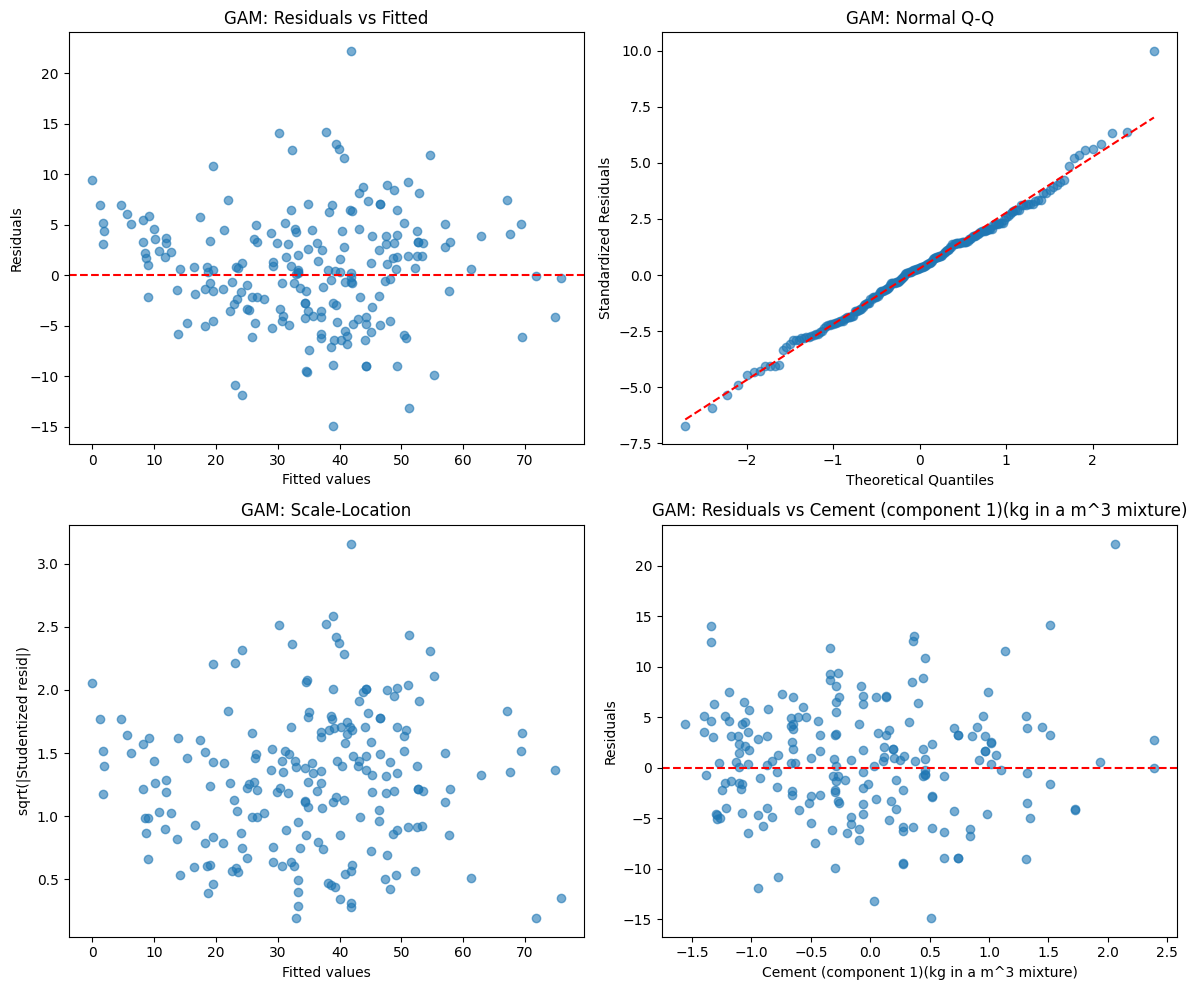

GAM Breusch-Pagan: stat=19.684, p=0.011600


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# --- Residuals on test set (consistent with your GLM comparisons) ---
y_test_pred_gam = gam.predict(X_test)
resid_gam = y_test - y_test_pred_gam
fitted_gam = y_test_pred_gam

n = len(y_test)

# --- Studentized-ish residuals (approximate, using GAM's own scale estimate) ---
scale = gam.statistics_['scale']
student_resid_gam = resid_gam / np.sqrt(scale)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted
axes[0,0].scatter(fitted_gam, resid_gam, alpha=0.6)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel("Fitted values")
axes[0,0].set_ylabel("Residuals")
axes[0,0].set_title("GAM: Residuals vs Fitted")

# Normal Q-Q
(osm, osr), (slope, intercept, r) = stats.probplot(student_resid_gam, dist="norm")
axes[0,1].scatter(osm, osr, alpha=0.6)
axes[0,1].plot(osm, slope * osm + intercept, color='red', linestyle='--')
axes[0,1].set_xlabel("Theoretical Quantiles")
axes[0,1].set_ylabel("Standardized Residuals")
axes[0,1].set_title("GAM: Normal Q-Q")

# Scale-Location
axes[1,0].scatter(fitted_gam, np.sqrt(np.abs(student_resid_gam)), alpha=0.6)
axes[1,0].set_xlabel("Fitted values")
axes[1,0].set_ylabel("sqrt(|Studentized resid|)")
axes[1,0].set_title("GAM: Scale-Location")

# Residuals vs each strongest-EDoF predictor (Cement, as an example) -- or loop all 8
axes[1,1].scatter(X_test[:, 0], resid_gam, alpha=0.6)
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_xlabel(feature_names[0])
axes[1,1].set_ylabel("Residuals")
axes[1,1].set_title(f"GAM: Residuals vs {feature_names[0]}")

plt.tight_layout()
plt.show()

# --- Formal Breusch-Pagan test on GAM residuals ---
X_test_const = sm.add_constant(X_test, has_constant='add')
bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(resid_gam, X_test_const)
print(f"GAM Breusch-Pagan: stat={bp_stat:.3f}, p={bp_pvalue:.6f}")

In [ ]:
outlier_idx = np.argsort(np.abs(resid_gam))[::-1][:5]
print("Top 5 largest-residual observations (GAM, test set):")
print(outlier_idx, resid_gam[outlier_idx])

Top 5 largest-residual observations (GAM, test set):
[ 54 188 168  80 203] [ 22.17564459 -14.89083899  14.15729461  14.03765937 -13.16399829]


In [ ]:
from pygam import LinearGAM, s, te
import numpy as np

terms = s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + te(0, 3) 

gam_interaction = LinearGAM(terms).gridsearch(X_train, y_train, lam=np.logspace(-3, 3, 5))

print(gam_interaction.summary())

  0% (0 of 5) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 20% (1 of 5) |#####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 40% (2 of 5) |##########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 60% (3 of 5) |###############           | Elapsed Time: 0:00:00 ETA:   0:00:00
 80% (4 of 5) |####################      | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:02 Time:  0:00:02


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    128.3117
Link Function:                     IdentityLink Log Likelihood:                                 -2374.9733
Number of Samples:                          824 AIC:                                             5008.5699
                                                AICc:                                            5057.1531
                                                GCV:                                               30.1108
                                                Scale:                                                4.67
                                                Pseudo R-Squared:                                   0.9352
Feature Function                  Lam

C:\Users\takun\AppData\Local\Temp\ipykernel_37108\2648505499.py:8: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_interaction.summary())


In [ ]:
from sklearn.metrics import mean_squared_error

y_test_pred_gam_int = gam_interaction.predict(X_test)
test_mse_gam_int = mean_squared_error(y_test, y_test_pred_gam_int)

print(f"GAM (with interaction) test MSE: {test_mse_gam_int:.3f}")
print(f"GAM (additive only) test MSE:    30.528")
print(f"Unregularized GLM test MSE:      44.582")
print(f"Regularized GLM test MSE:        61.852")

GAM (with interaction) test MSE: 30.996
GAM (additive only) test MSE:    30.528
Unregularized GLM test MSE:      44.582
Regularized GLM test MSE:        61.852


In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

resid_gam_int = y_test - y_test_pred_gam_int
X_test_const = sm.add_constant(X_test, has_constant='add')

bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(resid_gam_int, X_test_const)
print(f"GAM (with interaction) BP test: stat={bp_stat:.3f}, p={bp_pvalue:.6f}")

GAM (with interaction) BP test: stat=17.620, p=0.024260


In [ ]:
from pygam import LinearGAM, s, te
import numpy as np

terms = s(0, n_splines=25) + s(1, n_splines=25) + s(2, n_splines=15) + s(3, n_splines=20) + \
        s(4, n_splines=15) + s(5, n_splines=15) + s(6, n_splines=10) + s(7, n_splines=10) + te(0,3)   

gam_spline_specified = LinearGAM(terms).gridsearch(X_train, y_train, lam=np.logspace(-3, 3, 5))

print(gam_spline_specified.summary())

  0% (0 of 5) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--


 20% (1 of 5) |#####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 40% (2 of 5) |##########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 60% (3 of 5) |###############           | Elapsed Time: 0:00:00 ETA:   0:00:00
 80% (4 of 5) |####################      | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:01 Time:  0:00:01


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    115.8397
Link Function:                     IdentityLink Log Likelihood:                                 -2410.2262
Number of Samples:                          824 AIC:                                             5054.1319
                                                AICc:                                            5093.1269
                                                GCV:                                               31.1748
                                                Scale:                                              4.8374
                                                Pseudo R-Squared:                                   0.9292
Feature Function                  Lam

C:\Users\takun\AppData\Local\Temp\ipykernel_37108\1386007263.py:9: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_spline_specified.summary())


In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

y_test_pred_gam_spline = gam_spline_specified.predict(X_test)
test_mse_gam_spline = mean_squared_error(y_test, y_test_pred_gam_spline)

resid_gam_spline = y_test - y_test_pred_gam_spline
X_test_const = sm.add_constant(X_test, has_constant='add')

bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(resid_gam_spline, X_test_const)
print(f"GAM (with interaction) BP test: stat={bp_stat:.3f}, p={bp_pvalue:.6f}")

GAM (with interaction) BP test: stat=20.122, p=0.009884


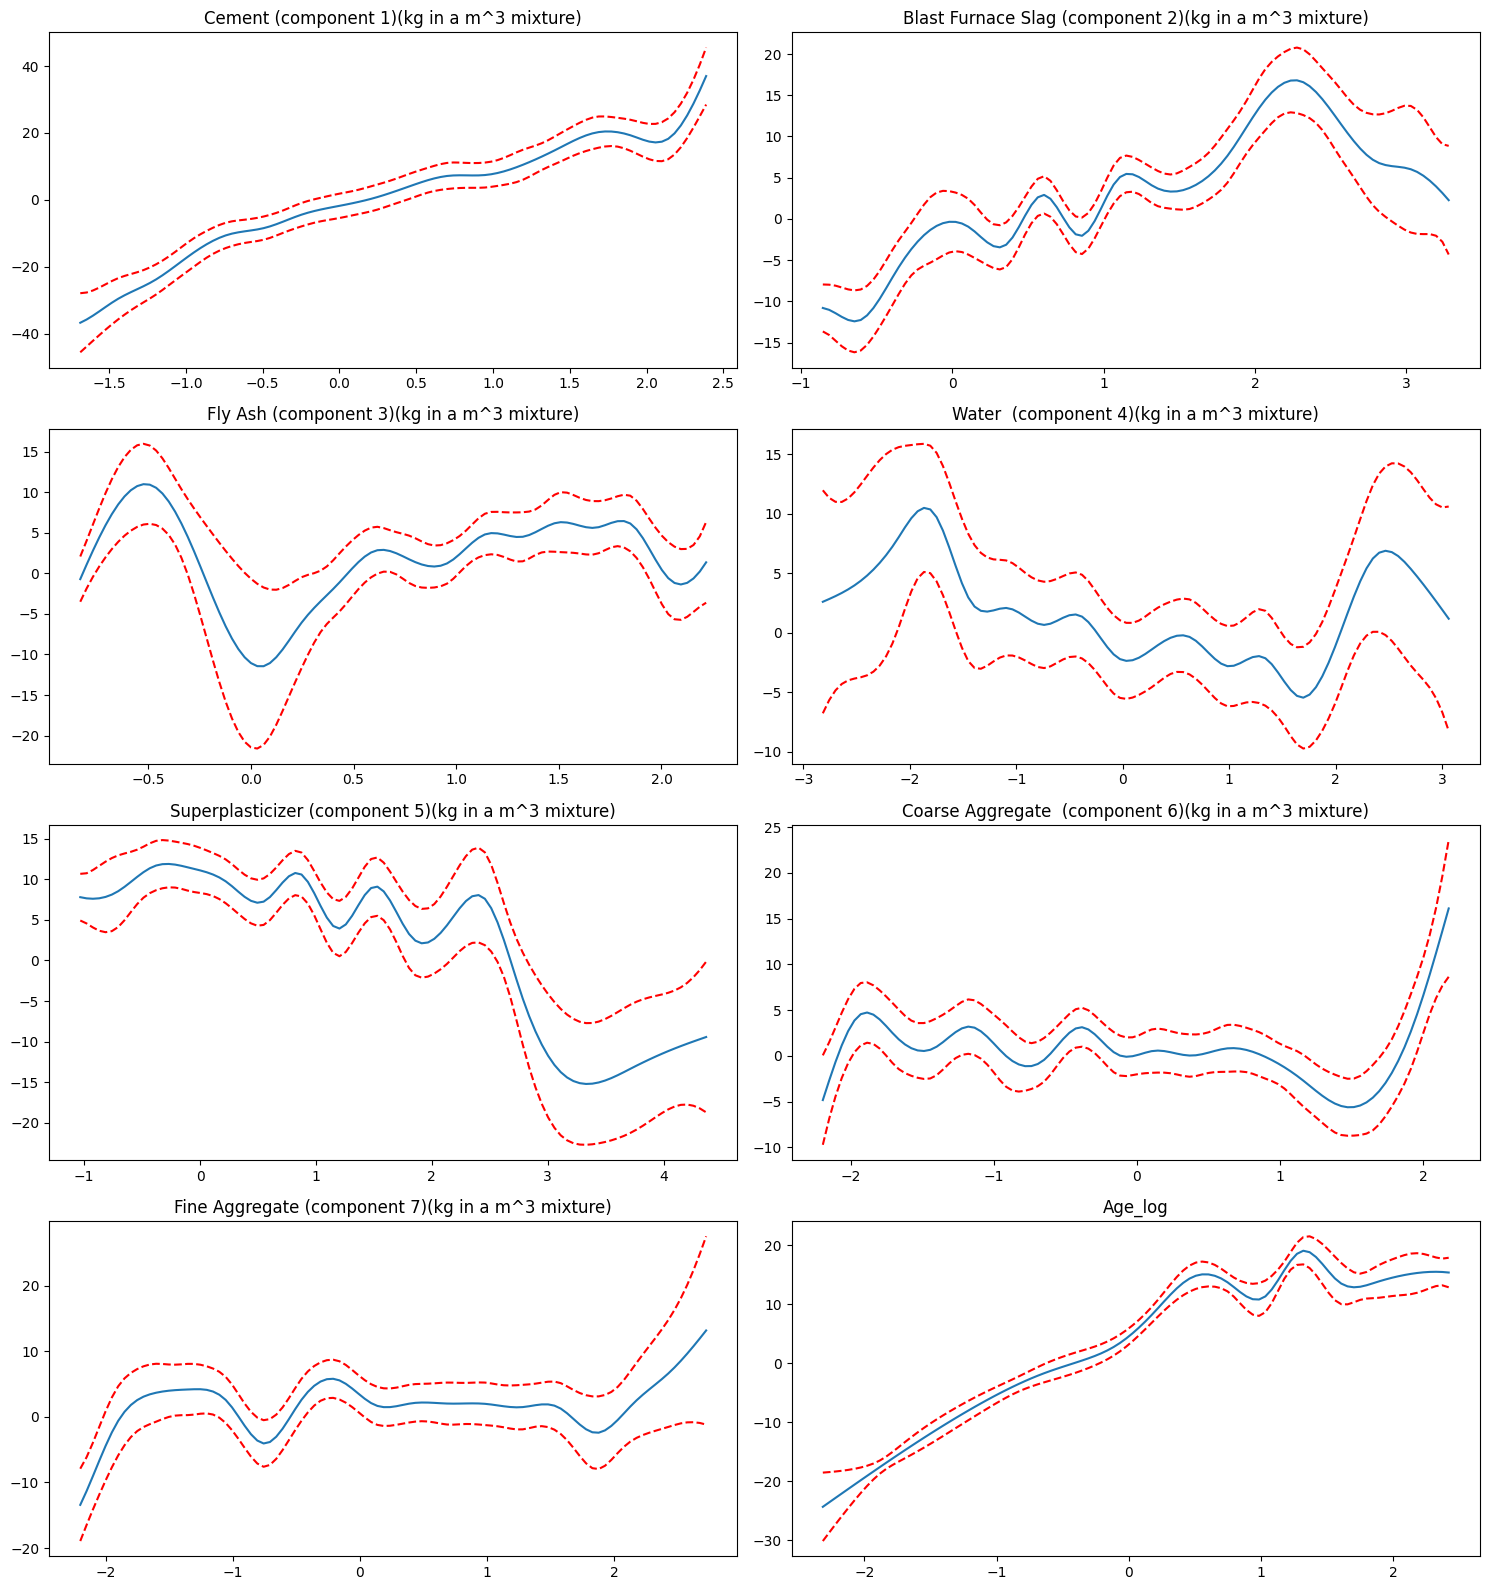

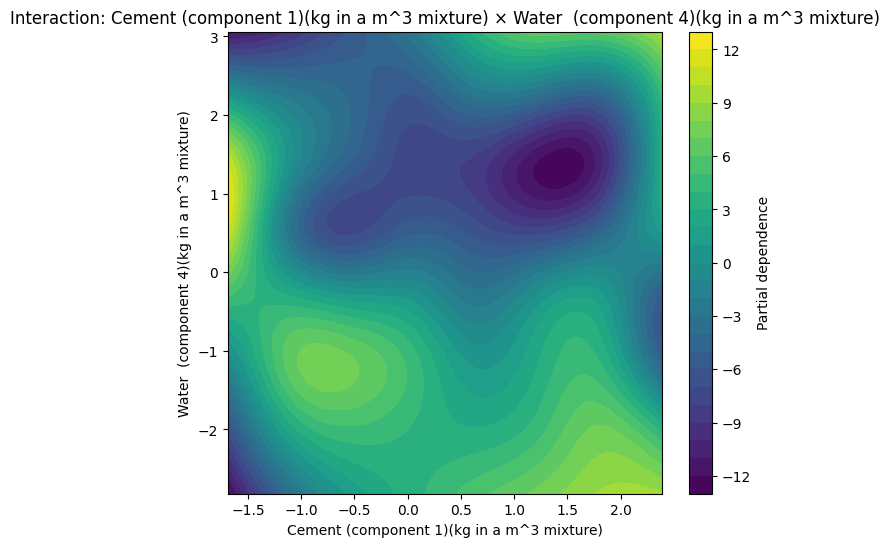

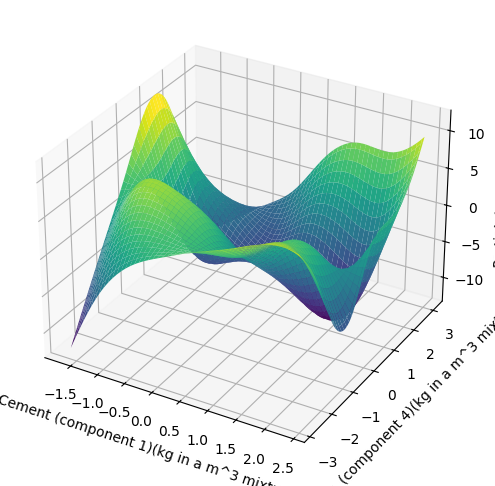

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n_main_terms = 8  # number of s(i) terms, adjust if different
interaction_term_idx = 8  # te(0,3) is the 9th term in your `terms` list, index 8

n_cols = 2
n_rows = int(np.ceil(n_main_terms / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

# --- plot the single-feature smooths ---
for i in range(n_main_terms):
    ax = axes[i]
    XX = gam_interaction.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam_interaction.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam_interaction.partial_dependence(term=i, X=XX, width=0.95)[1], c='r', ls='--')
    ax.set_title(feature_labels[i])

for j in range(n_main_terms, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# --- plot the interaction term separately as a 2D contour ---
XX_int = gam_interaction.generate_X_grid(term=interaction_term_idx, meshgrid=True)
Z = gam_interaction.partial_dependence(term=interaction_term_idx, X=XX_int, meshgrid=True)

fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(XX_int[0], XX_int[1], Z, levels=25, cmap='viridis')
fig.colorbar(cs, ax=ax, label="Partial dependence")
ax.set_xlabel(feature_labels[0])   # Cement
ax.set_ylabel(feature_labels[3])   # Water
ax.set_title(f"Interaction: {feature_labels[0]} × {feature_labels[3]}")
plt.show()

# --- optional: 3D surface view ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XX_int[0], XX_int[1], Z, cmap='viridis')
ax.set_xlabel(feature_labels[0])
ax.set_ylabel(feature_labels[3])
ax.set_zlabel("Partial dependence")
plt.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(
    x=XX_int[0], y=XX_int[1], z=Z,
    colorscale='Viridis',
    colorbar=dict(title="Partial dependence")
)])

fig.update_layout(
    title=f"Interaction: {feature_labels[0]} × {feature_labels[3]}",
    scene=dict(
        xaxis_title=feature_labels[0],
        yaxis_title=feature_labels[3],
        zaxis_title="Partial dependence"
    ),
    width=800, height=700
)

fig.show()

In [ ]:

# try forcing a higher minimum lambda in the search
lam_grid = np.logspace(0, 4, 10)  
gam_smoother = LinearGAM(terms).gridsearch(X_train, y_train, lam=lam_grid)
print(gam_smoother.summary())

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 10% (1 of 10) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01
 20% (2 of 10) |#####                    | Elapsed Time: 0:00:00 ETA:   0:00:02
 30% (3 of 10) |#######                  | Elapsed Time: 0:00:00 ETA:   0:00:01
 40% (4 of 10) |##########               | Elapsed Time: 0:00:01 ETA:   0:00:01
 50% (5 of 10) |############             | Elapsed Time: 0:00:01 ETA:   0:00:01
 60% (6 of 10) |###############          | Elapsed Time: 0:00:01 ETA:   0:00:01
 70% (7 of 10) |#################        | Elapsed Time: 0:00:02 ETA:   0:00:00
 80% (8 of 10) |####################     | Elapsed Time: 0:00:03 ETA:   0:00:00
 90% (9 of 10) |######################   | Elapsed Time: 0:00:03 ETA:   0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:03 Time:  0:00:03


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     73.6388
Link Function:                     IdentityLink Log Likelihood:                                 -2495.9429
Number of Samples:                          824 AIC:                                             5141.1636
                                                AICc:                                            5156.2515
                                                GCV:                                               32.5674
                                                Scale:                                               5.232
                                                Pseudo R-Squared:                                   0.9123
Feature Function                  Lam

C:\Users\takun\AppData\Local\Temp\ipykernel_37108\1604266025.py:4: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_smoother.summary())


In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

y_test_pred_gam_smooth = gam_smoother.predict(X_test)
test_mse_gam_smooth = mean_squared_error(y_test, y_test_pred_gam_smooth)

resid_gam_smooth = y_test - y_test_pred_gam_smooth
X_test_const = sm.add_constant(X_test, has_constant='add')

bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(resid_gam_smooth, X_test_const)
print(f"GAM (with interaction) BP test: stat={bp_stat:.3f}, p={bp_pvalue:.6f}")

GAM (with interaction) BP test: stat=23.592, p=0.002682


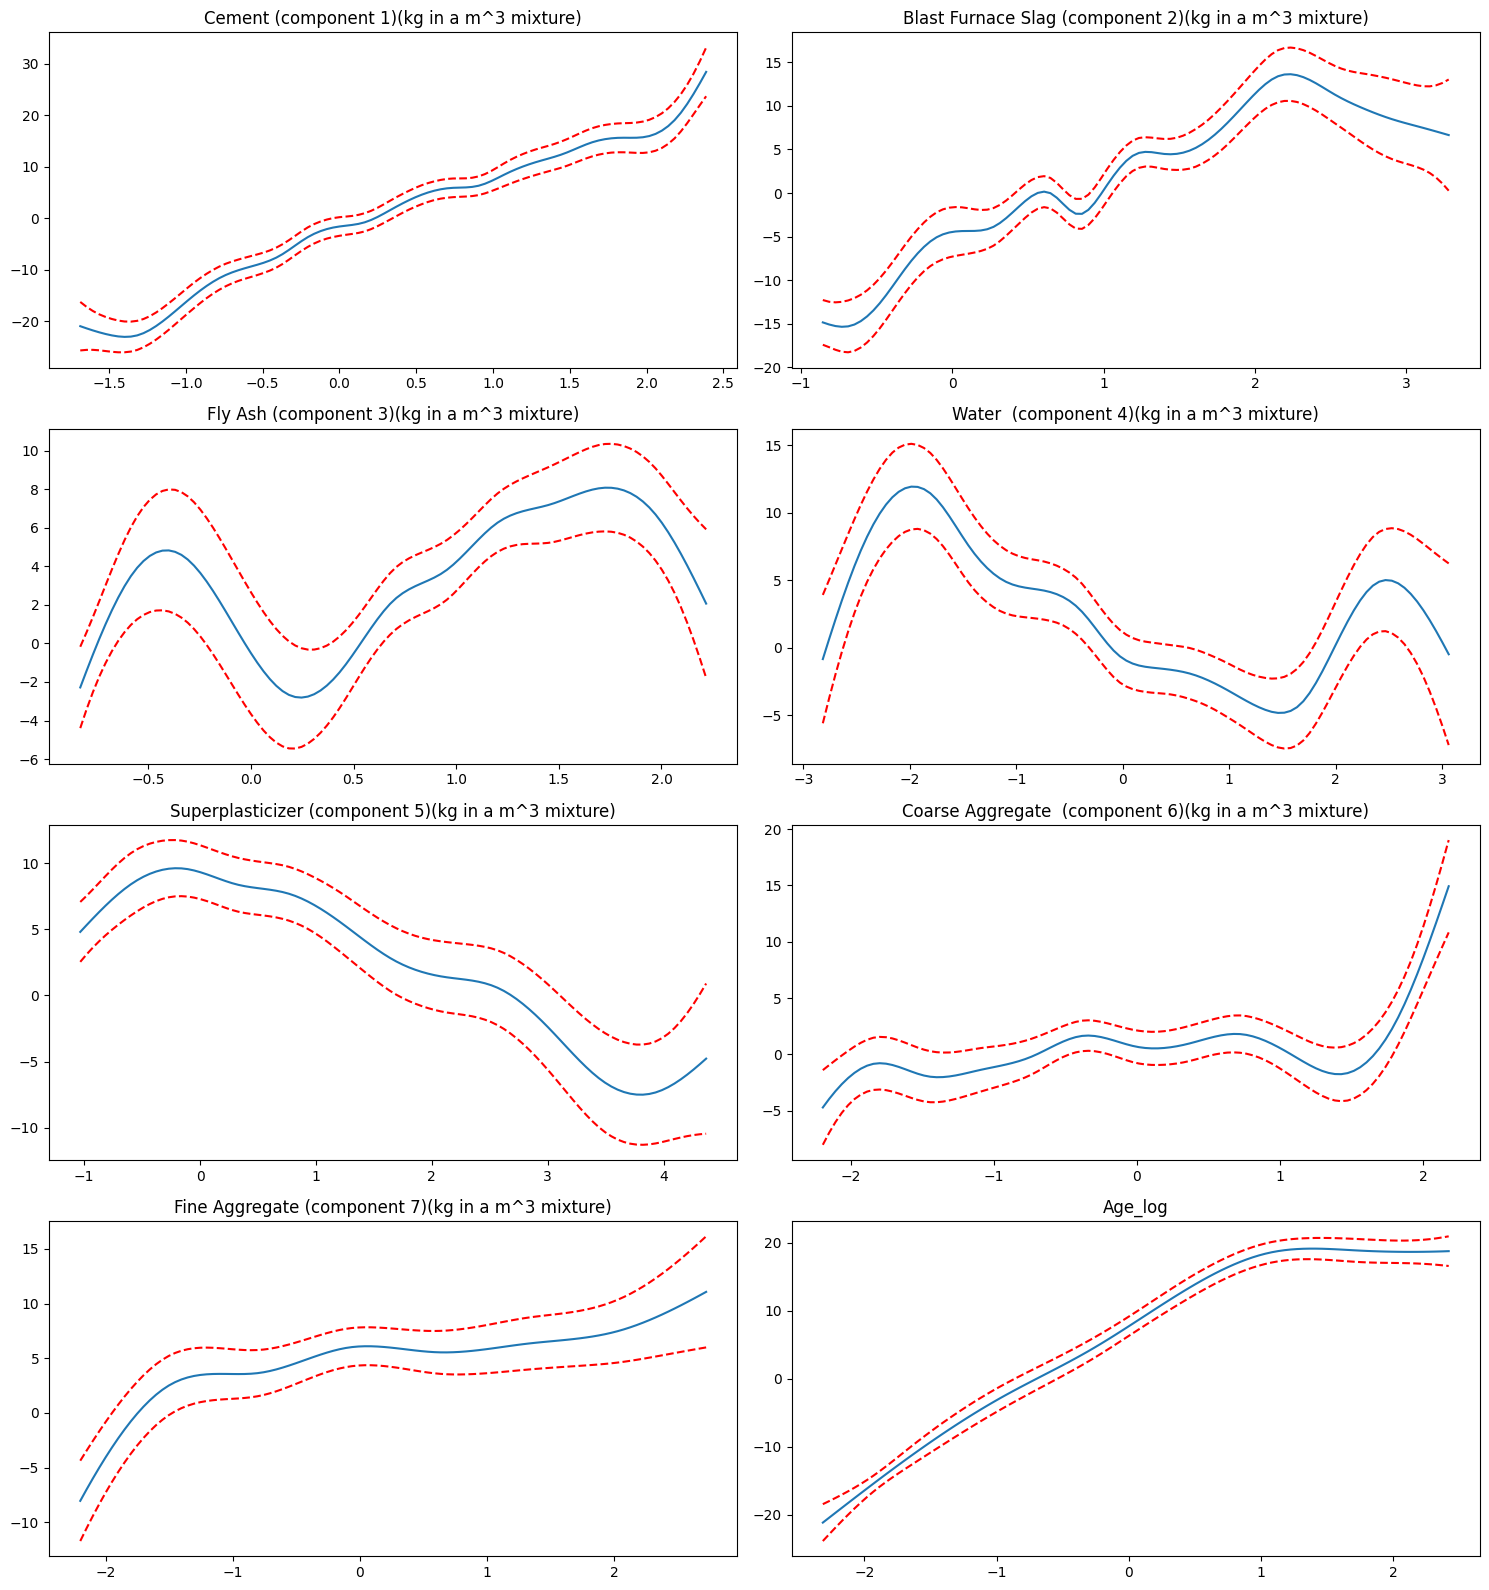

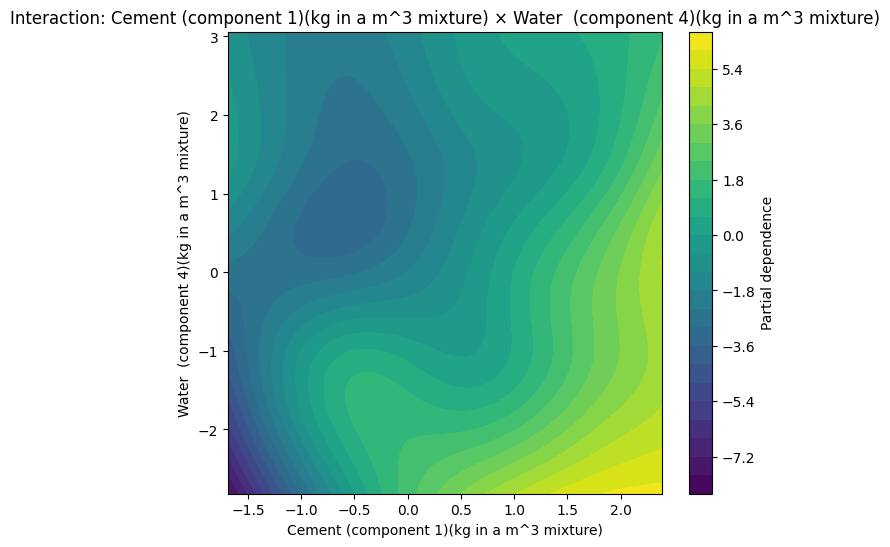

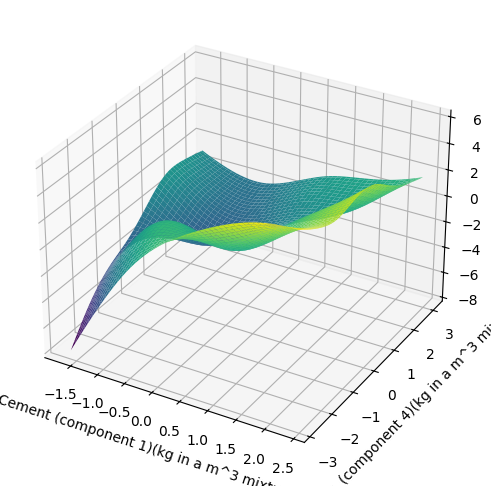

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n_main_terms = 8  # number of s(i) terms, adjust if different
interaction_term_idx = 8  # te(0,3) is the 9th term in your `terms` list, index 8

n_cols = 2
n_rows = int(np.ceil(n_main_terms / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

# --- plot the single-feature smooths ---
for i in range(n_main_terms):
    ax = axes[i]
    XX = gam_smoother.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam_smoother.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam_smoother.partial_dependence(term=i, X=XX, width=0.95)[1], c='r', ls='--')
    ax.set_title(feature_labels[i])

for j in range(n_main_terms, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# --- plot the interaction term separately as a 2D contour ---
XX_int = gam_smoother.generate_X_grid(term=interaction_term_idx, meshgrid=True)
Z = gam_smoother.partial_dependence(term=interaction_term_idx, X=XX_int, meshgrid=True)

fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(XX_int[0], XX_int[1], Z, levels=25, cmap='viridis')
fig.colorbar(cs, ax=ax, label="Partial dependence")
ax.set_xlabel(feature_labels[0])   # Cement
ax.set_ylabel(feature_labels[3])   # Water
ax.set_title(f"Interaction: {feature_labels[0]} × {feature_labels[3]}")
plt.show()

# --- optional: 3D surface view ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XX_int[0], XX_int[1], Z, cmap='viridis')
ax.set_xlabel(feature_labels[0])
ax.set_ylabel(feature_labels[3])
ax.set_zlabel("Partial dependence")
plt.show()

                                             feature    VIF
0          Cement (component 1)(kg in a m^3 mixture) 7.5242
1  Blast Furnace Slag (component 2)(kg in a m^3 m... 7.1064
2  Fine Aggregate (component 7)(kg in a m^3 mixture) 6.7805
3          Water  (component 4)(kg in a m^3 mixture) 6.5010
4         Fly Ash (component 3)(kg in a m^3 mixture) 5.9988
5  Coarse Aggregate  (component 6)(kg in a m^3 mi... 4.9329
6  Superplasticizer (component 5)(kg in a m^3 mix... 2.8680
7                                            Age_log 1.0485


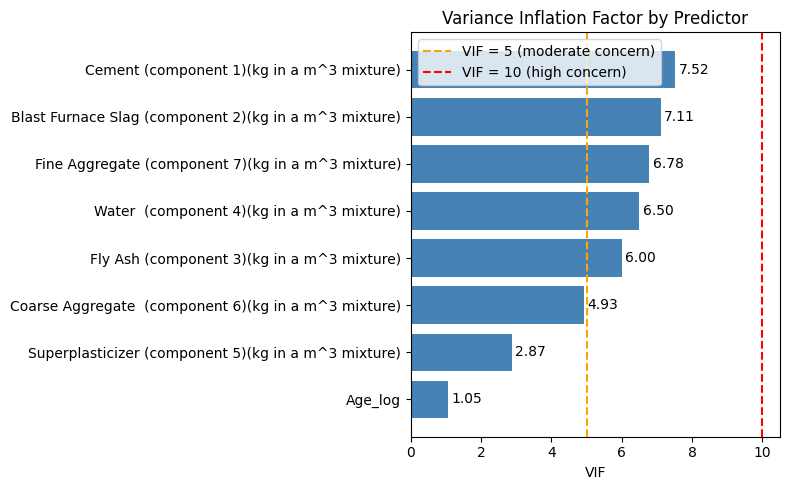

In [ ]:
vif_df = calculate_vif(X_train, feature_names=feature_names)
print(vif_df)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(vif_df["feature"], vif_df["VIF"], color='steelblue')

ax.axvline(5, color='orange', linestyle='--', label='VIF = 5 (moderate concern)')
ax.axvline(10, color='red', linestyle='--', label='VIF = 10 (high concern)')

ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor by Predictor")
ax.invert_yaxis()  
ax.legend()

# annotate bars with exact values
for bar, val in zip(bars, vif_df["VIF"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va='center')

plt.tight_layout()
plt.show()

In [ ]:
from pygam import LinearGAM, s, te
from functools import reduce
import operator

# example: test Fly Ash x Cement interaction (indices depend on your feature_names order)
fly_ash_idx = feature_names.index("Fly Ash (component 3)(kg in a m^3 mixture)")
cement_idx = feature_names.index("Cement (component 1)(kg in a m^3 mixture)")



term_list = [s(i) for i in range(8) if i != fly_ash_idx]
terms_test = reduce(operator.add, term_list) + te(fly_ash_idx, cement_idx)

gam_test = LinearGAM(terms_test).gridsearch(X_train, y_train, lam=np.logspace(0, 4, 8))
print(gam_test.summary())

  0% (0 of 8) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--


 12% (1 of 8) |###                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 25% (2 of 8) |######                    | Elapsed Time: 0:00:00 ETA:   0:00:01
 37% (3 of 8) |#########                 | Elapsed Time: 0:00:00 ETA:   0:00:01
 50% (4 of 8) |#############             | Elapsed Time: 0:00:01 ETA:   0:00:01
 62% (5 of 8) |################          | Elapsed Time: 0:00:01 ETA:   0:00:00
 75% (6 of 8) |###################       | Elapsed Time: 0:00:01 ETA:   0:00:00
 87% (7 of 8) |######################    | Elapsed Time: 0:00:02 ETA:   0:00:00
100% (8 of 8) |##########################| Elapsed Time: 0:00:02 Time:  0:00:02


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     77.7493
Link Function:                     IdentityLink Log Likelihood:                                  -2466.916
Number of Samples:                          824 AIC:                                             5091.3307
                                                AICc:                                            5108.2072
                                                GCV:                                               30.8268
                                                Scale:                                              5.0636
                                                Pseudo R-Squared:                                   0.9183
Feature Function                  Lam

C:\Users\takun\AppData\Local\Temp\ipykernel_37108\469547492.py:15: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_test.summary())


In [ ]:
from sklearn.metrics import mean_squared_error

y_test_pred_gam_int = gam_interaction.predict(X_test)
test_mse_gam_int = mean_squared_error(y_test, y_test_pred_gam_int)

y_test_pred_test = gam_test.predict(X_test)
test_mse_gam_test = mean_squared_error(y_test, y_test_pred_test)


print(f"GAM (with interaction) test MSE: {test_mse_gam_int:.3f}")
print(f"GAM (with test interaction) test MSE: {test_mse_gam_test:.3f}")
print(f"GAM (with smooth) test MSE: {test_mse_gam_smooth:.3f}")
print(f"GAM (with additive splines) test MSE: {test_mse_gam_spline:.3f}")
print(f"GAM (additive only) test MSE:    30.528")
print(f"Unregularized GLM test MSE:      44.582")
print(f"Regularized GLM test MSE:        61.852")

GAM (with interaction) test MSE: 30.996
GAM (with test interaction) test MSE: 31.426
GAM (with smooth) test MSE: 32.099
GAM (with additive splines) test MSE: 29.313
GAM (additive only) test MSE:    30.528
Unregularized GLM test MSE:      44.582
Regularized GLM test MSE:        61.852
